**1. ¿Qué categorías generan el mayor ingreso y cuáles deberían recibir mayor inversión?**  

**Objetivo gerencial: Priorizar presupuesto comercial e inventario.**  

**Variables involucradas:**  

•	categoria  
•	precio  
•	cantidad  

**KPIs esperados:**  

•	Ingreso total  
•	Participación porcentual  
•	Unidades vendidas  
•	Ticket promedio  

**Python que practicarás:**  

•	groupby()  
•	columnas calculadas (ventas = precio * cantidad)  
•	sort_values()  
•	gráficos de barras


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ventas_bogota_limpiar.csv', sep = ';', encoding = 'utf-8')
df

,id_venta,fecha,producto,categoria,precio,cantidad,ciudad,metodo_pago,cliente_satisfecho
0,1,13/02/2024,Monitor,Accesorios,1140503.31,6,Barranquilla,Tarjeta,si
1,2,29/02/2024,Audífonos,Accesorios,2786223.89,2,Barranquilla,NaN,si
2,3,5/04/2024,Teclado,Accesorios,958850.40,3,Cali,NaN,No
3,4,12/05/2024,Audífonos,Periféricos,1544815.40,5,Barranquilla,Efectivo,NaN
4,5,13/05/2024,Audífonos,Periféricos,NaN,9,bogotá,tarjeta,Sí
...,...,...,...,...,...,...,...,...,...
200,11,14/04/2024,Monitor,Periféricos,618930.71,8,bogotá,NaN,NO
201,12,26/02/2024,Teclado,Periféricos,560183.09,1,Bogotá,Tarjeta,si
202,13,29/04/2024,Audífonos,Periféricos,887096.50,6,Medellín,Efectivo,Sí
203,14,23/05/2024,Mouse,Accesorios,1929054.93,1,Cali,tarjeta,si


In [2]:
df["ventas"] = df["precio"] * df["cantidad"]

In [3]:
df.groupby("categoria")["ventas"].sum()

categoria
Accesorios     5.482465e+08
Electrónica    5.329718e+08
Periféricos    5.633076e+08
Name: ventas, dtype: float64

In [41]:
resumen = (
    df.groupby("categoria")
      .agg(
          Ingreso_Total=("ventas", "sum"), # DINERO GENERADO POR CADA CATEGORIA
          Unidades_Vendidas=("cantidad", "sum"), # CANTIDAD TOTAL DE PRODUCTOS VENDIDOS
          Ticket_Promedio=("ventas", "mean") # INGRESO PROMEDIO POR TRANSACCION
      )
      .sort_values("Ingreso_Total", ascending=False)
      .round(2)
)

resumen

,Ingreso_Total,Unidades_Vendidas,Ticket_Promedio
categoria,,,
Periféricos,5.633076e+08,346,8407575.61
Accesorios,5.482465e+08,320,8434561.61
Electrónica,5.329718e+08,318,9189169.53


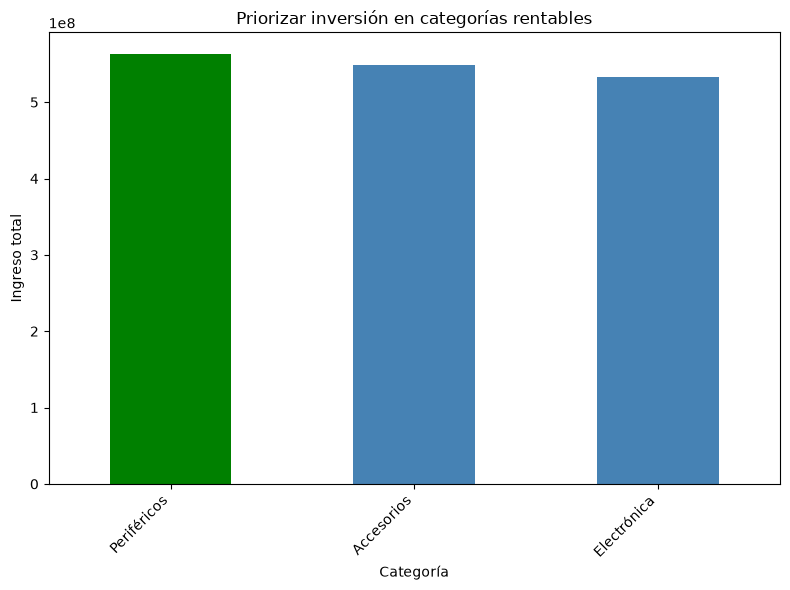

In [ ]:
indice_maximo = resumen["Ingreso_Total"].idxmax() # idmax encuentra la categoria mas alta y se pinta de verde

colores = ["steelblue"] * len(resumen)
posicion_maxima = resumen.index.get_loc(indice_maximo)
colores[posicion_maxima] = "green"

resumen["Ingreso_Total"].plot(
    kind="bar",
    color=colores,
    figsize=(8, 6)
)

plt.title("Priorizar inversión en categorías rentables")
plt.ylabel("Ingreso total")
plt.xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**2. ¿En qué ciudades estamos vendiendo mejor y dónde existen oportunidades de crecimiento?**  

Objetivo gerencial: Definir estrategia regional y asignación de recursos.  

Variables:
•	ciudad
•	precio
•	cantidad  

KPIs:
•	Ventas por ciudad
•	Número de transacciones
•	Ingreso promedio por venta
•	Ranking de ciudades  

Valor para la dirección:
Una ciudad puede tener muchas ventas pero poco ingreso, mientras otra puede tener pocas ventas con alto valor económico.



In [9]:
df['ciudad'].str.replace("BOGOTA", "Bogotá")

0      Barranquilla
1      Barranquilla
2              Cali
3      Barranquilla
4            bogotá
           ...     
200          bogotá
201          Bogotá
202        Medellín
203            Cali
204             NaN
Name: ciudad, Length: 205, dtype: str

In [34]:
# LIMPIEZA COLUMNA CIUDAD:

df["ciudad"] = (
    df["ciudad"]
    .str.strip()
    .str.upper()
    .replace({"BOGOTA": "BOGOTÁ"})
    .str.title()
)
df["ciudad"]

0      Barranquilla
1      Barranquilla
2              Cali
3      Barranquilla
4            Bogotá
           ...     
200          Bogotá
201          Bogotá
202        Medellín
203            Cali
204             NaN
Name: ciudad, Length: 205, dtype: str

In [35]:
df.groupby("ciudad")["ventas"].sum()

ciudad
Barranquilla    2.662134e+08
Bogotá          7.860170e+08
Cali            2.393811e+08
Medellín        2.453065e+08
Name: ventas, dtype: float64

In [36]:
resumen_ciudades = (
    df.groupby("ciudad")
      .agg(
          Ventas_Totales=("ventas", "sum"),
          Numero_Transacciones=("ventas", "size"),
          Ingreso_Promedio=("ventas", "mean")
      )
      .sort_values("Ventas_Totales", ascending=False)
)

resumen_ciudades

,Ventas_Totales,Numero_Transacciones,Ingreso_Promedio
ciudad,,,
Bogotá,7.860170e+08,100,8.543663e+06
Barranquilla,2.662134e+08,33,8.873779e+06
Medellín,2.453065e+08,28,8.760947e+06
Cali,2.393811e+08,35,7.480660e+06


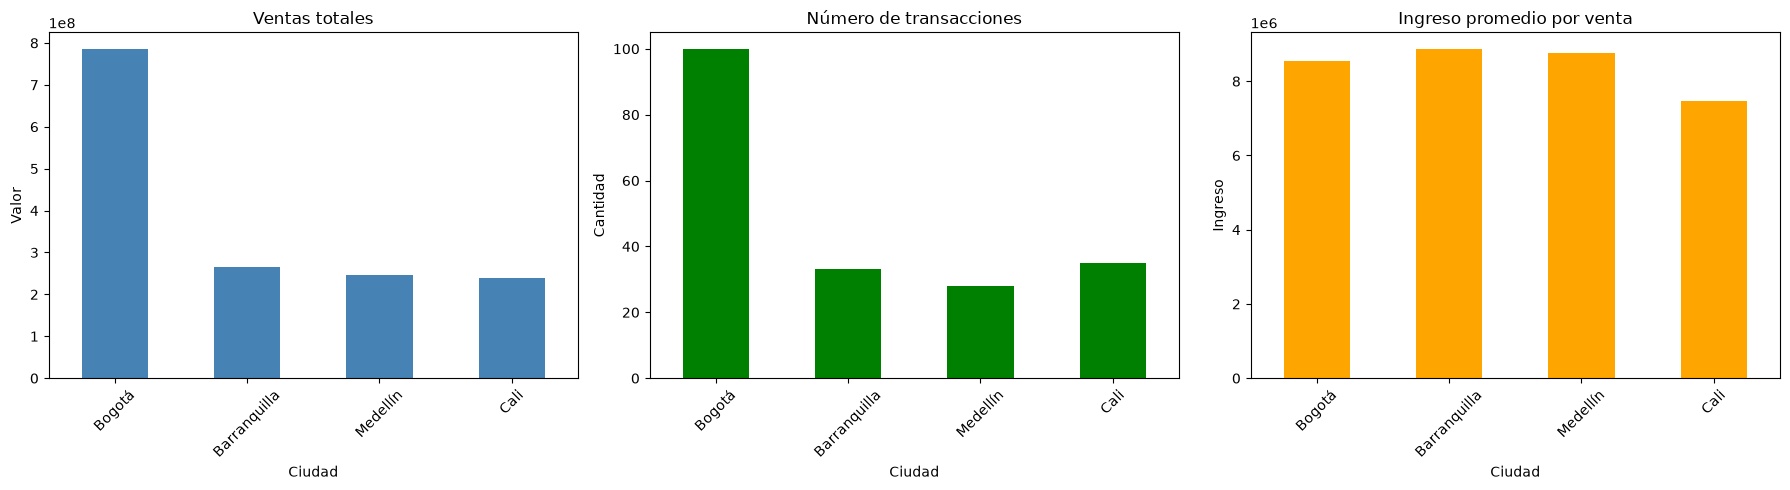

In [40]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

# Ventas totales
resumen_ciudades["Ventas_Totales"].plot(
    kind="bar",
    ax=ejes[0],
    color="steelblue"
)
ejes[0].set_title("Ventas totales")
ejes[0].set_xlabel("Ciudad")
ejes[0].set_ylabel("Valor")
ejes[0].tick_params(axis="x", rotation=45)

# Número de transacciones
resumen_ciudades["Numero_Transacciones"].plot(
    kind="bar",
    ax=ejes[1],
    color="green"
)
ejes[1].set_title("Número de transacciones")
ejes[1].set_xlabel("Ciudad")
ejes[1].set_ylabel("Cantidad")
ejes[1].tick_params(axis="x", rotation=45)

# Ingreso promedio
resumen_ciudades["Ingreso_Promedio"].plot(
    kind="bar",
    ax=ejes[2],
    color="orange"
)
ejes[2].set_title("Ingreso promedio por venta")
ejes[2].set_xlabel("Ciudad")
ejes[2].set_ylabel("Ingreso")
ejes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()